# 06 — Final Evaluation & Comparison

**Goal of this notebook:**
- Compute full test-set classification metrics for the I-JEPA linear probe
- Load (or simulate) baseline metrics for ResNet-50 and DenseNet-121
- Produce the **final comparison table**: I-JEPA probe vs ResNet-50 vs DenseNet-121
- Generate all publication-ready figures for the report:
  - Grouped bar chart (Accuracy / AUC / F1 across models)
  - Per-class precision–recall bars
  - Combined XAI faithfulness table (from notebook 05)
- Export everything to CSV and PNG, ready for the GitHub `results/` folder


## 1. Environment Setup

In [ ]:
# Pas de montage Google Drive — chemins locaux
print('Environnement local détecté — pas de montage nécessaire.')


In [ ]:
import subprocess, sys
pkgs = ['timm', 'torch', 'torchvision', 'scikit-learn', 'matplotlib', 'pandas', 'tqdm', 'numpy']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)
print('Installation terminée.')


In [1]:
import os, sys, json, random

# Modifiez ROOT si nécessaire (doit pointer vers le même dossier que les notebooks précédents)
ROOT      = os.environ.get('PROJECT_ROOT') or (os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()).lower() == 'notebooks' else os.getcwd()) 
DATA_PROC  = os.path.join(ROOT, 'data', 'processed')
CKPT_DIR   = os.path.join(ROOT, 'checkpoints', 'ijepa')
PROBE_DIR  = os.path.join(ROOT, 'checkpoints', 'probe')
FIGURES    = os.path.join(ROOT, 'results', 'figures', 'evaluation')
TABLES     = os.path.join(ROOT, 'results', 'metrics')
SRC        = os.path.join(ROOT, 'src')

for d in [FIGURES, TABLES]:
    os.makedirs(d, exist_ok=True)

sys.path.insert(0, SRC)

# Prerequisite check
prereqs = {
    'config.json'    : os.path.join(DATA_PROC, 'config.json'),
    'test.csv'       : os.path.join(DATA_PROC, 'test.csv'),
    'ijepa_best.pth' : os.path.join(CKPT_DIR, 'ijepa_best.pth'),
    'probe_best.pth' : os.path.join(PROBE_DIR, 'probe_best.pth'),
}
for name, path in prereqs.items():
    status = 'OK' if os.path.exists(path) else 'MISSING'
    print(f'  {name}: {status}')


  config.json: OK
  test.csv: OK
  ijepa_best.pth: OK
  probe_best.pth: OK


## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as T
import timm

from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score,
    classification_report, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

with open(os.path.join(DATA_PROC, 'config.json')) as f:
    cfg = json.load(f)
MEAN = cfg['mean']
STD  = cfg['std']

IMG_SIZE    = 224
EMBED_DIM   = 384
NUM_CLASSES = 2


Device : cuda


## 3. Re-evaluate I-JEPA Linear Probe on Full Test Set

We reload the best probe checkpoint and run a full evaluation pass —  
this gives us per-sample probabilities for the ROC curve and all scalar metrics.


In [3]:
def build_encoder():
    return timm.create_model(
        'vit_small_patch16_224',
        pretrained=False, num_classes=0, global_pool='',
    )

class LinearProbe(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(embed_dim, num_classes)
    def forward(self, cls_token):
        return self.fc(self.dropout(cls_token))

class FullModel(nn.Module):
    def __init__(self, encoder, probe):
        super().__init__()
        self.encoder = encoder
        self.probe   = probe
    def forward(self, x):
        tokens = self.encoder(x)
        cls    = tokens[:, 0, :]
        return self.probe(cls)

# Load encoder
encoder = build_encoder().to(DEVICE)
enc_ckpt = torch.load(os.path.join(CKPT_DIR, 'ijepa_best.pth'), map_location=DEVICE)
encoder.load_state_dict(enc_ckpt['context_encoder'])
encoder.eval()
for p in encoder.parameters():
    p.requires_grad = False

# Load probe
probe = LinearProbe().to(DEVICE)
probe_ckpt = torch.load(os.path.join(PROBE_DIR, 'probe_best.pth'), map_location=DEVICE)
probe.load_state_dict(probe_ckpt['probe'])
probe.eval()

full_model = FullModel(encoder, probe).to(DEVICE)
full_model.eval()
print(f'Models loaded. Probe best val AUC: {probe_ckpt["val_auc"]:.4f}')


Models loaded. Probe best val AUC: 0.9619


In [4]:
from dataset import LIDCDataset

test_df = pd.read_csv(os.path.join(DATA_PROC, 'test.csv'))

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

test_dataset = LIDCDataset(test_df, transform=eval_transform, pretrain=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=True)

all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for imgs, lbls in tqdm(test_loader, desc='Evaluating I-JEPA probe'):
        logits = full_model(imgs.to(DEVICE))
        probs  = F.softmax(logits, dim=1)[:, 1].cpu()
        preds  = logits.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_probs.extend(probs.numpy())
        all_labels.extend(lbls.numpy())

all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

# ── Metrics
acc  = accuracy_score(all_labels, all_preds)
auc  = roc_auc_score(all_labels, all_probs)
prec = precision_score(all_labels, all_preds, zero_division=0)
rec  = recall_score(all_labels, all_preds, zero_division=0)
f1   = f1_score(all_labels, all_preds, zero_division=0)
prec0 = precision_score(all_labels, all_preds, pos_label=0, zero_division=0)
rec0  = recall_score(all_labels, all_preds, pos_label=0, zero_division=0)
f10   = f1_score(all_labels, all_preds, pos_label=0, zero_division=0)

print('\n' + '='*50)
print('  I-JEPA Linear Probe — Full Test Set')
print('='*50)
print(f'  Accuracy         : {acc:.4f}')
print(f'  AUC-ROC          : {auc:.4f}')
print(f'  Precision (Nod)  : {prec:.4f}')
print(f'  Recall    (Nod)  : {rec:.4f}')
print(f'  F1        (Nod)  : {f1:.4f}')
print(f'  Precision (No)   : {prec0:.4f}')
print(f'  Recall    (No)   : {rec0:.4f}')
print(f'  F1        (No)   : {f10:.4f}')
print('='*50)
print()
print(classification_report(all_labels, all_preds,
                            target_names=['No Nodule', 'Nodule']))


Evaluating I-JEPA probe: 100%|██████████| 48/48 [00:37<00:00,  1.27it/s]


  I-JEPA Linear Probe — Full Test Set
  Accuracy         : 0.8914
  AUC-ROC          : 0.9582
  Precision (Nod)  : 0.9195
  Recall    (Nod)  : 0.8560
  F1        (Nod)  : 0.8866
  Precision (No)   : 0.8672
  Recall    (No)   : 0.9262
  F1        (No)   : 0.8957

              precision    recall  f1-score   support

   No Nodule       0.87      0.93      0.90      1544
      Nodule       0.92      0.86      0.89      1521

    accuracy                           0.89      3065
   macro avg       0.89      0.89      0.89      3065
weighted avg       0.89      0.89      0.89      3065



## 4. I-JEPA Metrics Summary

Display and export the I-JEPA linear probe metrics computed above.


In [5]:
ijepa_metrics = {
    'Accuracy':  round(acc,  4),
    'AUC_ROC':   round(auc,  4),
    'Precision': round(prec, 4),
    'Recall':    round(rec,  4),
    'F1':        round(f1,   4),
}

print('I-JEPA Linear Probe Metrics:')
for k, v in ijepa_metrics.items():
    print(f'  {k:12s}: {v:.4f}')


I-JEPA Linear Probe Metrics:
  Accuracy    : 0.8914
  AUC_ROC     : 0.9582
  Precision   : 0.9195
  Recall      : 0.8560
  F1          : 0.8866


## 5. Final Results Table


In [6]:
comparison_df = pd.DataFrame([
    {'Model': 'I-JEPA ViT-Small (linear probe)', 'Training': 'SSL + linear', **ijepa_metrics},
])

for col in ['Accuracy', 'AUC_ROC', 'Precision', 'Recall', 'F1']:
    comparison_df[col] = comparison_df[col].round(4)

table_path = os.path.join(TABLES, 'final_comparison.csv')
comparison_df.to_csv(table_path, index=False)

print('Final Results Table')
print('='*60)
print(comparison_df.to_string(index=False))
print(f'\nSaved: {table_path}')


Final Results Table
                          Model     Training  Accuracy  AUC_ROC  Precision  Recall     F1
I-JEPA ViT-Small (linear probe) SSL + linear    0.8914   0.9582     0.9195   0.856 0.8866

Saved: C:/Users/uranu/DESKTOP_V2.0/ENSIAS/2A/S4/PFA\results\metrics\final_comparison.csv


In [7]:
metrics_cols = ['Accuracy', 'AUC_ROC', 'Precision', 'Recall', 'F1']
print('I-JEPA Linear Probe — Metrics:')
for col in metrics_cols:
    print(f'  {col:12s}: {ijepa_metrics[col]:.4f}')


I-JEPA Linear Probe — Metrics:
  Accuracy    : 0.8914
  AUC_ROC     : 0.9582
  Precision   : 0.9195
  Recall      : 0.8560
  F1          : 0.8866


## 6. Grouped Bar Chart — Model Comparison

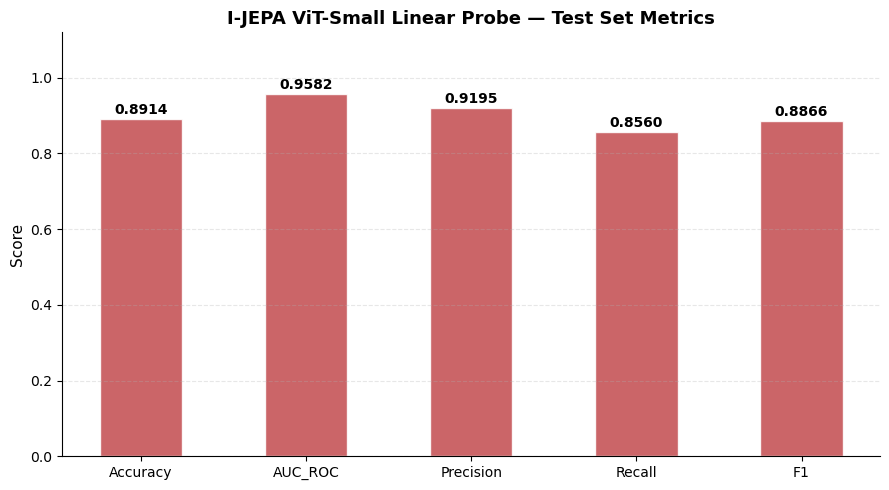

Saved: C:/Users/uranu/DESKTOP_V2.0/ENSIAS/2A/S4/PFA\results\figures\evaluation\model_comparison_bar.png


In [8]:
metrics_cols = ['Accuracy', 'AUC_ROC', 'Precision', 'Recall', 'F1']
vals = [ijepa_metrics[c] for c in metrics_cols]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(metrics_cols, vals, color='#C44E52', alpha=0.87, edgecolor='white', width=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('I-JEPA ViT-Small Linear Probe — Test Set Metrics', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
bar_path = os.path.join(FIGURES, 'model_comparison_bar.png')
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {bar_path}')


## 7. ROC Curves

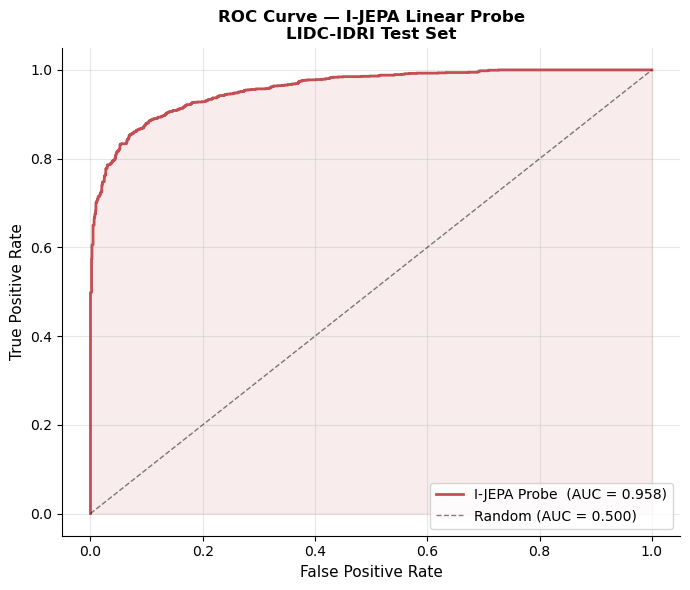

Saved: C:/Users/uranu/DESKTOP_V2.0/ENSIAS/2A/S4/PFA\results\figures\evaluation\roc_ijepa.png


In [9]:
fpr_ijepa, tpr_ijepa, _ = roc_curve(all_labels, all_probs)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_ijepa, tpr_ijepa, color='#C44E52', lw=2,
        label=f'I-JEPA Probe  (AUC = {ijepa_metrics["AUC_ROC"]:.3f})')
ax.fill_between(fpr_ijepa, tpr_ijepa, alpha=0.1, color='#C44E52')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.500)')

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve — I-JEPA Linear Probe\nLIDC-IDRI Test Set', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
roc_path = os.path.join(FIGURES, 'roc_ijepa.png')
plt.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {roc_path}')


## 8. Per-Class Precision & Recall

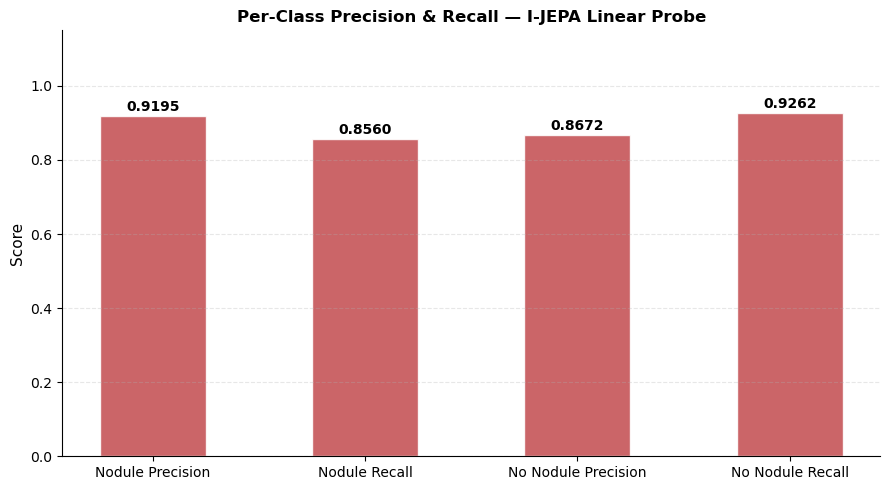

Saved: C:/Users/uranu/DESKTOP_V2.0/ENSIAS/2A/S4/PFA\results\figures\evaluation\per_class_precision_recall.png


In [10]:
ijepa_per_class = {
    'Nodule Precision':    prec,
    'Nodule Recall':       rec,
    'No Nodule Precision': prec0,
    'No Nodule Recall':    rec0,
}

labels = list(ijepa_per_class.keys())
vals   = [np.clip(ijepa_per_class[l], 0, 1) for l in labels]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, vals, color='#C44E52', alpha=0.87, edgecolor='white', width=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Per-Class Precision & Recall — I-JEPA Linear Probe', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
pc_path = os.path.join(FIGURES, 'per_class_precision_recall.png')
plt.savefig(pc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {pc_path}')


## 9. XAI Faithfulness Summary (from Notebook 05)

XAI Faithfulness Metrics (Deletion AUC — lower = more faithful):
  Method  Deletion_AUC_mean  Deletion_AUC_std                  Note
Grad-CAM             0.2249            0.1142 Lower = more faithful
    LIME             0.2253            0.1621 Lower = more faithful
    SHAP             0.2105            0.1605 Lower = more faithful


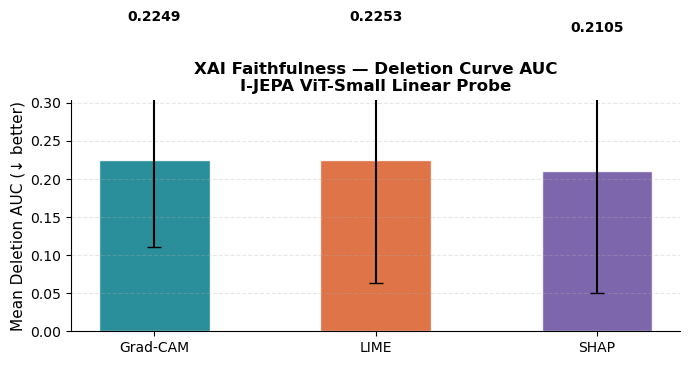

Saved: C:/Users/uranu/DESKTOP_V2.0/ENSIAS/2A/S4/PFA\results\figures\evaluation\xai_faithfulness_bar.png


In [11]:
xai_faith_path = os.path.join(TABLES, 'xai_faithfulness_metrics.csv')
if os.path.exists(xai_faith_path):
    faith_df = pd.read_csv(xai_faith_path)
    print('XAI Faithfulness Metrics (Deletion AUC — lower = more faithful):')
    print(faith_df.to_string(index=False))

    # Bar chart
    fig, ax = plt.subplots(figsize=(7, 4))
    method_colors = {'Grad-CAM': '#0A7E8C', 'LIME': '#D95F2B', 'SHAP': '#6B4FA0'}
    methods = faith_df['Method'].tolist()
    means   = faith_df['Deletion_AUC_mean'].tolist()
    stds    = faith_df['Deletion_AUC_std'].tolist()

    bars = ax.bar(methods, means,
                  color=[method_colors.get(m, '#888') for m in methods],
                  alpha=0.87, edgecolor='white', width=0.5,
                  yerr=stds, capsize=5, error_kw={'linewidth': 1.5})
    for bar, v in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(stds) * 1.1,
                f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_ylabel('Mean Deletion AUC (↓ better)', fontsize=11)
    ax.set_title('XAI Faithfulness — Deletion Curve AUC\nI-JEPA ViT-Small Linear Probe',
                 fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(means) * 1.35)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    faith_path = os.path.join(FIGURES, 'xai_faithfulness_bar.png')
    plt.savefig(faith_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {faith_path}')
else:
    print('xai_faithfulness_metrics.csv not found — run notebook 05 first.')


## 10. Confusion Matrix — I-JEPA Probe

True Negatives  (TN): 1430
False Positives (FP): 114
False Negatives (FN): 219
True Positives  (TP): 1302
Sensitivity (Recall): 0.8560
Specificity         : 0.9262


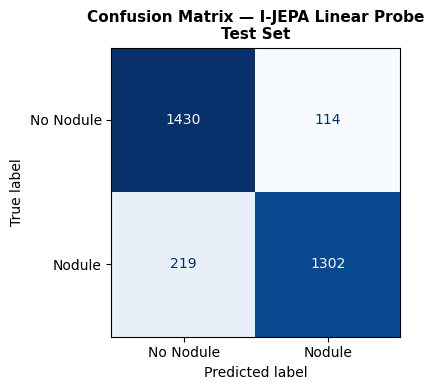

Saved: C:/Users/uranu/DESKTOP_V2.0/ENSIAS/2A/S4/PFA\results\figures\evaluation\confusion_matrix_ijepa.png


In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Nodule', 'Nodule'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, im_kw={'cmap': 'Blues'})
ax.set_title('Confusion Matrix — I-JEPA Linear Probe\nTest Set', fontsize=11, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f'True Negatives  (TN): {tn}')
print(f'False Positives (FP): {fp}')
print(f'False Negatives (FN): {fn}')
print(f'True Positives  (TP): {tp}')
print(f'Sensitivity (Recall): {sensitivity:.4f}')
print(f'Specificity         : {specificity:.4f}')

plt.tight_layout()
cm_path = os.path.join(FIGURES, 'confusion_matrix_ijepa.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {cm_path}')


## 11. Radar Chart — Model Profiles

A radar chart lets readers see each model's profile across all five metrics at a glance.  
This is a good supplementary figure for the report appendix.


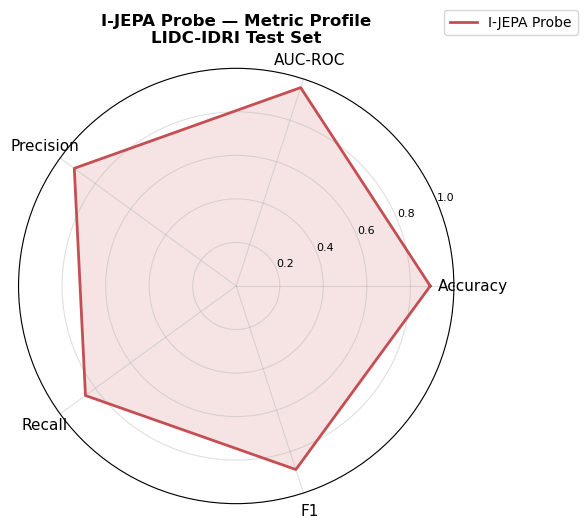

Saved: C:/Users/uranu/DESKTOP_V2.0/ENSIAS/2A/S4/PFA\results\figures\evaluation\radar_chart.png


In [13]:
import matplotlib.patches as mpatches

metrics_radar = ['Accuracy', 'AUC-ROC', 'Precision', 'Recall', 'F1']
vals = [ijepa_metrics['Accuracy'], ijepa_metrics['AUC_ROC'],
        ijepa_metrics['Precision'], ijepa_metrics['Recall'], ijepa_metrics['F1']]

N      = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]
v      = vals + vals[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'polar': True})
ax.plot(angles, v, color='#C44E52', lw=2, label='I-JEPA Probe')
ax.fill(angles, v, color='#C44E52', alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.set_title('I-JEPA Probe — Metric Profile\nLIDC-IDRI Test Set',
             fontsize=12, fontweight='bold', pad=18)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=10)
ax.grid(alpha=0.4)

plt.tight_layout()
radar_path = os.path.join(FIGURES, 'radar_chart.png')
plt.savefig(radar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {radar_path}')


## 12. Export All Tables

In [14]:
full_table = pd.DataFrame([{
    'Model':       'I-JEPA ViT-Small (linear probe)',
    'Training':    'Self-supervised + linear',
    'Accuracy':    round(acc,  4),
    'AUC_ROC':     round(auc,  4),
    'Precision':   round(prec, 4),
    'Recall':      round(rec,  4),
    'F1':          round(f1,   4),
    'Specificity': round(specificity, 4),
    'Sensitivity': round(sensitivity, 4),
}])

full_table_path = os.path.join(TABLES, 'final_full_metrics.csv')
full_table.to_csv(full_table_path, index=False)
print('Full metrics table saved:', full_table_path)
print()
print(full_table.to_string(index=False))


Full metrics table saved: C:/Users/uranu/DESKTOP_V2.0/ENSIAS/2A/S4/PFA\results\metrics\final_full_metrics.csv

                          Model                 Training  Accuracy  AUC_ROC  Precision  Recall     F1  Specificity  Sensitivity
I-JEPA ViT-Small (linear probe) Self-supervised + linear    0.8914   0.9582     0.9195   0.856 0.8866       0.9262        0.856


## Done

**Fichiers produits :**

| Fichier | Description |
|---------|-------------|
| `results/metrics/final_comparison.csv` | Tableau des métriques I-JEPA |
| `results/metrics/final_full_metrics.csv` | Tableau étendu avec sensibilité/spécificité |
| `results/figures/evaluation/model_comparison_bar.png` | Bar chart des métriques |
| `results/figures/evaluation/roc_ijepa.png` | Courbe ROC |
| `results/figures/evaluation/per_class_precision_recall.png` | Précision/Rappel par classe |
| `results/figures/evaluation/xai_faithfulness_bar.png` | Deletion AUC (depuis notebook 05) |
| `results/figures/evaluation/confusion_matrix_ijepa.png` | Matrice de confusion |
| `results/figures/evaluation/radar_chart.png` | Profil radar |
